# Principal Component Analysis

In this notebook we will see how we will use PCA to reduce dimensions and select most Useful Features. PCA helps us to find the features that can explain the movement of all variables in a dataset. The theory for this chapter (including Eigen Values and Eigen Vectors are written in Financial Data Notebook).


* Conducted Principal Component Analysis (PCA) on U.S. Treasury yields across multiple maturities (1M to 30Y) to uncover dominant factors driving yield curve movements.

* Standardized yield data and computed the covariance matrix to extract eigenvalues and eigenvectors, enabling interpretation of level, slope, and curvature components (PC1,PC2,PC3)

* Extracted principal components by computing eigenvectors and eigenvalues, revealing that PC1 captures the Parallel shift , PC2 captures the yield curve tilt between 2-year and 10-year maturities and PC3 captures the curvature of slope.

In [2]:
import pandas as pd
import numpy as np
from fredapi import Fred
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [3]:
# Initialize the FRED API with your key
fred = Fred(api_key='5079f41d061a4037d81f3da69e018803')

# List of Treasury yield series IDs, the yields are for 1 month, 3 months, 6 months, 1 year, 2 years, 3 years, 5 years.... 30 years
series_ids = ['DGS1MO', 'DGS3MO', 'DGS6MO', 'DGS1', 'DGS2', 'DGS3', 'DGS5',
              'DGS7', 'DGS10', 'DGS20', 'DGS30']

#function to get data for single series or single time Period
def get_series(series_id):
    data = fred.get_series(series_id, observation_start="1975-01-01",observation_end="2025-06-10")
    return data

#Get data for all the Series in form of dictionary 
yields_dict = {series_id: get_series(series_id) for series_id in series_ids}

#converting the dictionary into data frame
yields = pd.DataFrame(yields_dict)

#renaming columns for clarity 
yields.columns = ['1 Month', '3 Month', '6 Month', '1 Year', '2 Year', '3 Year', '5 Year', '7 Year', '10 Year', '20 Year', '30 Year']

In [4]:
yields = yields.dropna()
yields.index = pd.to_datetime(yields.index)
yields

,1 Month,3 Month,6 Month,1 Year,2 Year,3 Year,5 Year,7 Year,10 Year,20 Year,30 Year
2001-07-31,3.67,3.54,3.47,3.53,3.79,4.06,4.57,4.86,5.07,5.61,5.51
2001-08-01,3.65,3.53,3.47,3.56,3.83,4.09,4.62,4.90,5.11,5.63,5.53
2001-08-02,3.65,3.53,3.46,3.57,3.89,4.17,4.69,4.97,5.17,5.68,5.57
2001-08-03,3.63,3.52,3.47,3.57,3.91,4.22,4.72,4.99,5.20,5.70,5.59
2001-08-06,3.62,3.52,3.47,3.56,3.88,4.17,4.71,4.99,5.19,5.70,5.59
...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04,4.32,4.44,4.29,4.06,3.87,3.84,3.93,4.14,4.37,4.90,4.89
2025-06-05,4.26,4.44,4.29,4.08,3.92,3.90,3.99,4.18,4.40,4.90,4.88
2025-06-06,4.28,4.43,4.31,4.14,4.04,4.02,4.13,4.31,4.51,4.99,4.97
2025-06-09,4.29,4.44,4.32,4.13,4.01,3.99,4.09,4.28,4.49,4.98,4.95


To Find Principal components we first standardize the data (So that each yield contributes equally irrespective of the scale), after standardizing the data we find a covariance matrix of the Standardized data. We then Find the eigen vectors of that covariance Matrix, and then we multiply matrix of eigen vectors with Standardized data. The Eigen vector with highest eigen value gives us PC1, the second highest gives us PC2 and so on..

## Standardizing the Values

Standardizing the values means bringing those values on the same scale. The standardizing formula is given by :

$$Z=\frac{X-\mu}{\sigma}$$


In [5]:
yields

,1 Month,3 Month,6 Month,1 Year,2 Year,3 Year,5 Year,7 Year,10 Year,20 Year,30 Year
2001-07-31,3.67,3.54,3.47,3.53,3.79,4.06,4.57,4.86,5.07,5.61,5.51
2001-08-01,3.65,3.53,3.47,3.56,3.83,4.09,4.62,4.90,5.11,5.63,5.53
2001-08-02,3.65,3.53,3.46,3.57,3.89,4.17,4.69,4.97,5.17,5.68,5.57
2001-08-03,3.63,3.52,3.47,3.57,3.91,4.22,4.72,4.99,5.20,5.70,5.59
2001-08-06,3.62,3.52,3.47,3.56,3.88,4.17,4.71,4.99,5.19,5.70,5.59
...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04,4.32,4.44,4.29,4.06,3.87,3.84,3.93,4.14,4.37,4.90,4.89
2025-06-05,4.26,4.44,4.29,4.08,3.92,3.90,3.99,4.18,4.40,4.90,4.88
2025-06-06,4.28,4.43,4.31,4.14,4.04,4.02,4.13,4.31,4.51,4.99,4.97
2025-06-09,4.29,4.44,4.32,4.13,4.01,3.99,4.09,4.28,4.49,4.98,4.95


In [6]:
yields_mean = yields.mean()
yields_mean

1 Month    1.604441
3 Month    1.667288
6 Month    1.764411
1 Year     1.839341
2 Year     2.009077
3 Year     2.188591
5 Year     2.559408
7 Year     2.869036
10 Year    3.142691
20 Year    3.665809
30 Year    3.762185
dtype: float64

In [7]:
yields_std = yields.std()
yields_std

1 Month    1.813469
3 Month    1.826799
6 Month    1.819288
1 Year     1.737549
2 Year     1.583432
3 Year     1.474640
5 Year     1.323643
7 Year     1.233045
10 Year    1.174552
20 Year    1.197712
30 Year    1.097928
dtype: float64

In [8]:
#python is smart enough to apply column wise operation until your data dimension matches
standardized_data = (yields - yields_mean)/yields_std
standardized_data

,1 Month,3 Month,6 Month,1 Year,2 Year,3 Year,5 Year,7 Year,10 Year,20 Year,30 Year
2001-07-31,1.139010,1.025133,0.937504,0.973014,1.124723,1.269062,1.518983,1.614672,1.640888,1.623255,1.591920
2001-08-01,1.127981,1.019659,0.937504,0.990279,1.149985,1.289406,1.556758,1.647112,1.674944,1.639953,1.610137
2001-08-02,1.127981,1.019659,0.932007,0.996035,1.187877,1.343656,1.609642,1.703882,1.726027,1.681700,1.646569
2001-08-03,1.116953,1.014185,0.937504,0.996035,1.200508,1.377563,1.632307,1.720102,1.751569,1.698398,1.664785
2001-08-06,1.111438,1.014185,0.937504,0.990279,1.181562,1.343656,1.624752,1.720102,1.743055,1.698398,1.664785
...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04,1.497439,1.517798,1.388230,1.278041,1.175247,1.119873,1.035469,1.030752,1.044916,1.030458,1.027221
2025-06-05,1.464353,1.517798,1.388230,1.289552,1.206823,1.160561,1.080798,1.063192,1.070458,1.030458,1.018112
2025-06-06,1.475382,1.512324,1.399223,1.324083,1.282608,1.241936,1.186567,1.168622,1.164111,1.105601,1.100085
2025-06-09,1.480896,1.517798,1.404720,1.318328,1.263662,1.221592,1.156348,1.144292,1.147083,1.097252,1.081869


## Covariance Matrix of Standardized Data

We will now find Covariance Matrix of Standardized Data that is essentially same as correlation matrix of normal data but since we any ways need the standardized data later to get principal components. This data will tell us how yields at different maturity moves together.
Below we will get a 11 by 11 Matrix

In [9]:
std_data_cov = standardized_data.cov()
std_data_cov

,1 Month,3 Month,6 Month,1 Year,2 Year,3 Year,5 Year,7 Year,10 Year,20 Year,30 Year
1 Month,1.000000,0.996697,0.989474,0.978104,0.948078,0.914153,0.834384,0.757993,0.670364,0.539593,0.472594
3 Month,0.996697,1.000000,0.996895,0.988378,0.960349,0.926583,0.844591,0.765750,0.675364,0.541849,0.471623
6 Month,0.989474,0.996895,1.000000,0.996313,0.973392,0.941835,0.860454,0.780478,0.688732,0.552852,0.479417
1 Year,0.978104,0.988378,0.996313,1.000000,0.987966,0.962970,0.888587,0.811220,0.719800,0.584134,0.509033
2 Year,0.948078,0.960349,0.973392,0.987966,1.000000,0.992120,0.941199,0.876423,0.791908,0.663120,0.589597
3 Year,0.914153,0.926583,0.941835,0.962970,0.992120,1.000000,0.974387,0.925118,0.851639,0.734352,0.665075
5 Year,0.834384,0.844591,0.860454,0.888587,0.941199,0.974387,1.000000,0.986014,0.943504,0.858335,0.803610
7 Year,0.757993,0.765750,0.780478,0.811220,0.876423,0.925118,0.986014,1.000000,0.984064,0.928128,0.887050
10 Year,0.670364,0.675364,0.688732,0.719800,0.791908,0.851639,0.943504,0.984064,1.000000,0.976912,0.951637
20 Year,0.539593,0.541849,0.552852,0.584134,0.663120,0.734352,0.858335,0.928128,0.976912,1.000000,0.990129


Text(0.5, 1.0, 'Covariance Matrix of Standardized Treasury Bond Yields')

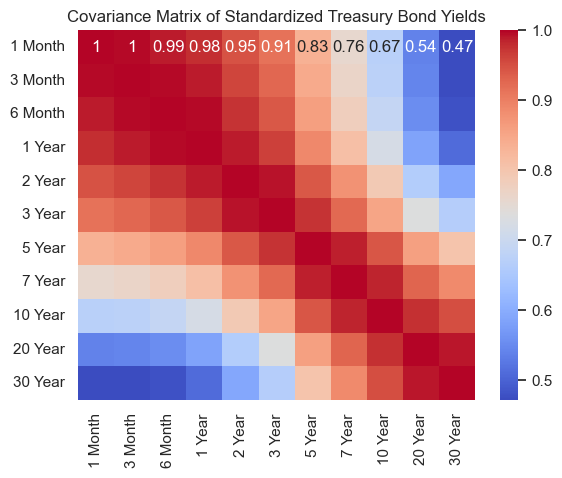

In [10]:
sns.heatmap(std_data_cov,annot=True, cmap = 'coolwarm')
plt.title('Covariance Matrix of Standardized Treasury Bond Yields')

## Eigen Vectors and Eigen Values

We will now find Eigen vectors and eigen values of Covariance Matrix, Eigen vectors of covariance are those vectors on which when Covariance Matrix acts it does not change the direction of eigen vectors, it just stretches them to the direction of maximum variability. Eigen vectors point out in the direction where data spreads the most. The first eigen vector with the highest eigen value explains the most variability. We have calculated eigen vectors in our notes so we won't calculate them again here we will just use the library.

In [11]:
from numpy import linalg as la

In [12]:
eigen_values, eigen_vectors = la.eig(std_data_cov)
eigen_values

array([9.28464389e+00, 1.57178040e+00, 1.17475812e-01, 1.44294057e-02,
       5.16595156e-03, 3.53870829e-03, 1.50186056e-03, 6.90092327e-04,
       3.89392612e-04, 2.31513129e-04, 1.52980562e-04])

The eigen values above are in descending order, similarly the corresponsing eigen vectors will also be in descending order. In PCA we call it eigen vector **Loadings**. The first eigen vector with highest eigen value will explain the most of the variability.


In [13]:
eigen_vectors

array([[ 0.29820671,  0.30482598,  0.44794515, -0.52245904,  0.14426778,
         0.35778951,  0.33420834, -0.27791101,  0.03635855, -0.07363188,
        -0.00597498],
       [ 0.30046251,  0.30704729,  0.33025691, -0.11154141, -0.07768615,
        -0.11594197, -0.4247253 ,  0.58861696, -0.16552951,  0.33441667,
         0.09142987],
       [ 0.30348317,  0.29798052,  0.17192092,  0.26027654, -0.21707313,
        -0.35500725, -0.13210106, -0.08446745,  0.33249616, -0.58318782,
        -0.27093695],
       [ 0.30880577,  0.26623137, -0.01950178,  0.4345557 , -0.09062736,
        -0.18793906,  0.13143504, -0.49237335, -0.14340865,  0.41262636,
         0.38790879],
       [ 0.31803688,  0.1764016 , -0.29002433,  0.30732818,  0.23100355,
         0.25301236,  0.25229768,  0.19208099, -0.36929393,  0.03997687,
        -0.57729284],
       [ 0.3228263 ,  0.08718747, -0.40857704,  0.06041706,  0.2354958 ,
         0.30968912, -0.02471461,  0.26554456,  0.23178747, -0.32660447,
         0.578

In [14]:
eigen_vectors.shape

(11, 11)

Above we have matrix of Eigen vectors where the first row is Eigen Vector 1, the second Row is eigen vector 2 and so on.. , we will now multiply this with our standardized data therefore our first row will be multiplied with first column of standardized data therefore the resulting first column in new data will be PC1 and will explain the most variability. Similarly the second new column will be PC2 and so on... (Explained the dimension multiplication in theory).

The most important feature of PCA is **the leading principal components can explain higher portions of the variance of the dataset than the rest of the principal components**.

In [15]:
principal_components = standardized_data.dot(eigen_vectors)
principal_components.columns = ['PC_1','PC_2','PC_3','PC_4','PC_5','PC_6','PC_7','PC_8','PC_9','PC_10','PC_11']
principal_components

,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10,PC_11
2001-07-31,4.325186,-1.033886,0.086599,-0.196819,0.008593,0.051834,0.008522,-0.004991,0.001786,0.018324,-0.001341
2001-08-01,4.381835,-1.066122,0.051033,-0.194590,0.008845,0.042795,0.014038,-0.008849,-0.000031,0.027514,-0.005621
2001-08-02,4.482091,-1.125322,0.004157,-0.205582,0.015738,0.053404,0.017234,-0.000090,-0.003187,0.026004,-0.002785
2001-08-03,4.522910,-1.153999,-0.021876,-0.200569,0.020078,0.053910,0.019170,0.009327,0.008014,0.017700,0.003006
2001-08-06,4.497531,-1.160061,-0.001786,-0.204610,0.009337,0.041283,0.009088,-0.000365,0.002954,0.022262,-0.006164
...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04,3.959834,0.349941,0.527161,0.007980,0.010409,0.010523,-0.033967,0.056674,-0.007631,-0.001620,0.009625
2025-06-05,4.006901,0.337367,0.456592,0.011059,0.006851,0.000370,-0.039813,0.069402,-0.006013,0.005061,0.009340
2025-06-06,4.209023,0.234659,0.384307,0.002234,0.022998,0.004566,-0.029911,0.059118,-0.009112,0.006484,0.000934
2025-06-09,4.170289,0.259313,0.412771,0.005478,0.011782,0.005105,-0.029155,0.061602,-0.008707,0.001608,0.003684


Let's see how much each of the PCs explain variation 

In [16]:
# Put data into a DataFrame
df_eigval = pd.DataFrame({"Eigenvalues":eigen_values}, index=range(1,12))

# Work out explained proportion
df_eigval["Explained proportion"] = df_eigval["Eigenvalues"] / np.sum(df_eigval["Eigenvalues"])
df_eigval.style.format({"Explained proportion": "{:.2%}"})

,Eigenvalues,Explained proportion
1,9.284644,84.41%
2,1.571780,14.29%
3,0.117476,1.07%
4,0.014429,0.13%
5,0.005166,0.05%
6,0.003539,0.03%
7,0.001502,0.01%
8,0.000690,0.01%
9,0.000389,0.00%
10,0.000232,0.00%


According to historical research on US treasury Yields, PC1 gives us parallel shift in the yield curve, PC2 gives us flattening or steepening of yield curve and PC3 gives us the curvature of yield curve

<Axes: >

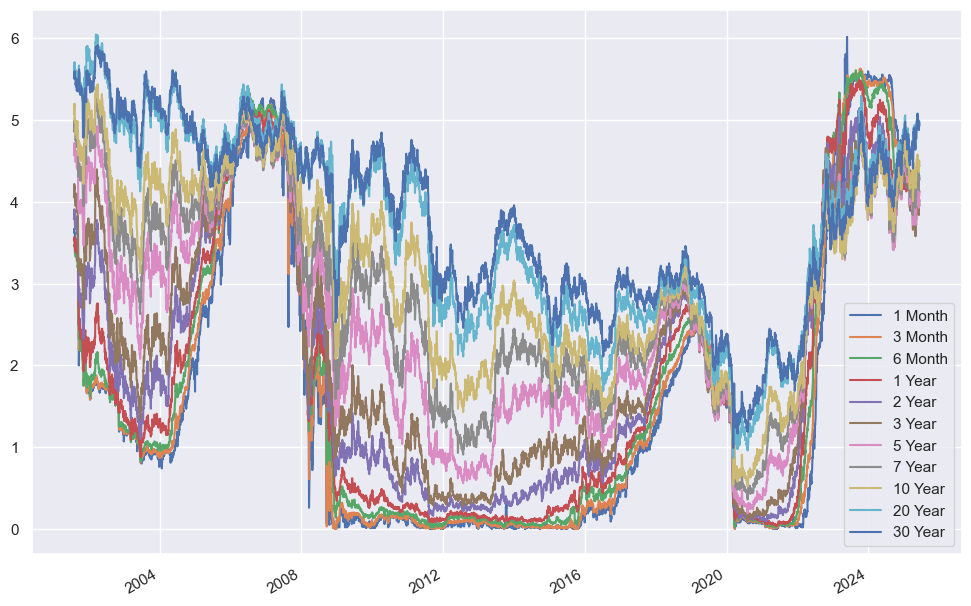

In [17]:
yields.plot(figsize=(12,8))

<Axes: >

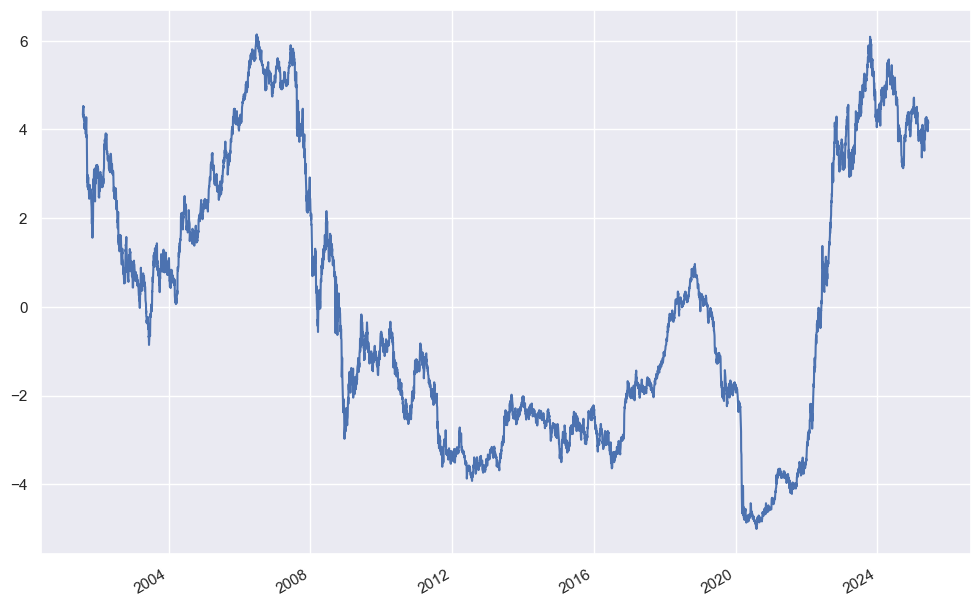

In [18]:
principal_components['PC_1'].plot(figsize=(12,8))

From the above figure we can see that the shape of PC1 is exactly similar to shapes across different maturities , this shows that PC1 is used to show the parallel shift in the yield curve.

Similarly let's see the tilt between 2 and 10 year yield curve and compare it with PC2

In [19]:
df_2 = pd.DataFrame(standardized_data)
df_2 = df_2[['2 Year','10 Year']]
df_2['Tilt'] = df_2['2 Year'] - df_2['10 Year']
df_2

,2 Year,10 Year,Tilt
2001-07-31,1.124723,1.640888,-0.516165
2001-08-01,1.149985,1.674944,-0.524959
2001-08-02,1.187877,1.726027,-0.538150
2001-08-03,1.200508,1.751569,-0.551061
2001-08-06,1.181562,1.743055,-0.561493
...,...,...,...
2025-06-04,1.175247,1.044916,0.130330
2025-06-05,1.206823,1.070458,0.136366
2025-06-06,1.282608,1.164111,0.118498
2025-06-09,1.263662,1.147083,0.116579


<Axes: >

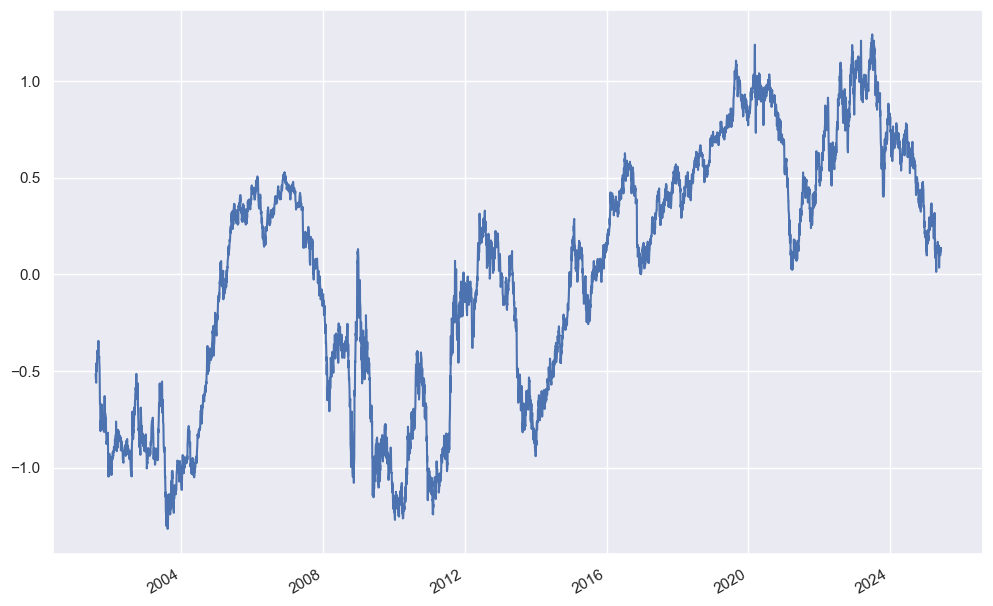

In [20]:
df_2['Tilt'].plot(figsize=(12,8))

<Axes: >

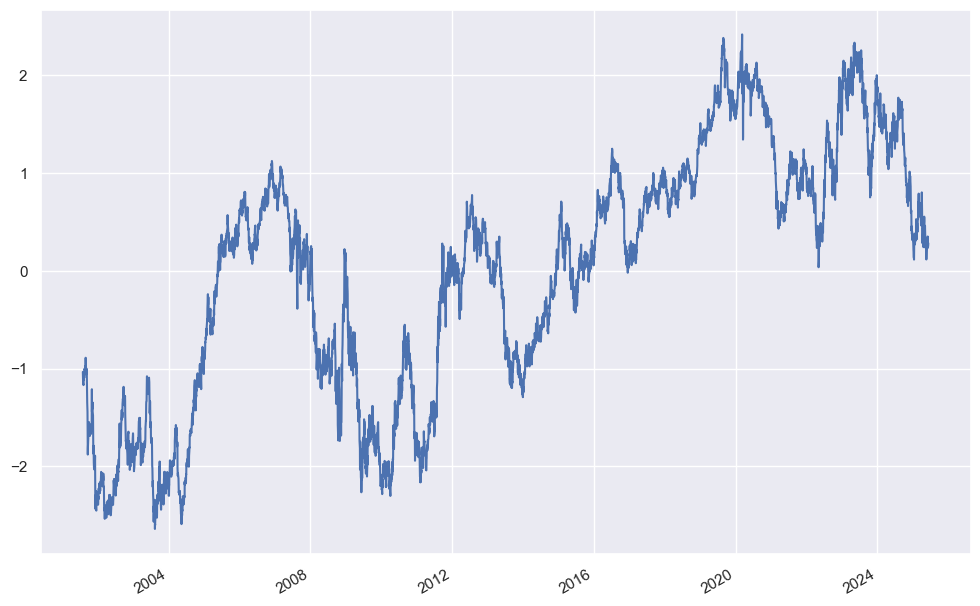

In [21]:
principal_components['PC_2'].plot(figsize=(12,8))

From the above graph we can see that PC2 is exactly mirroring the tilt between 2 year and 10 year yield curve

<Axes: >

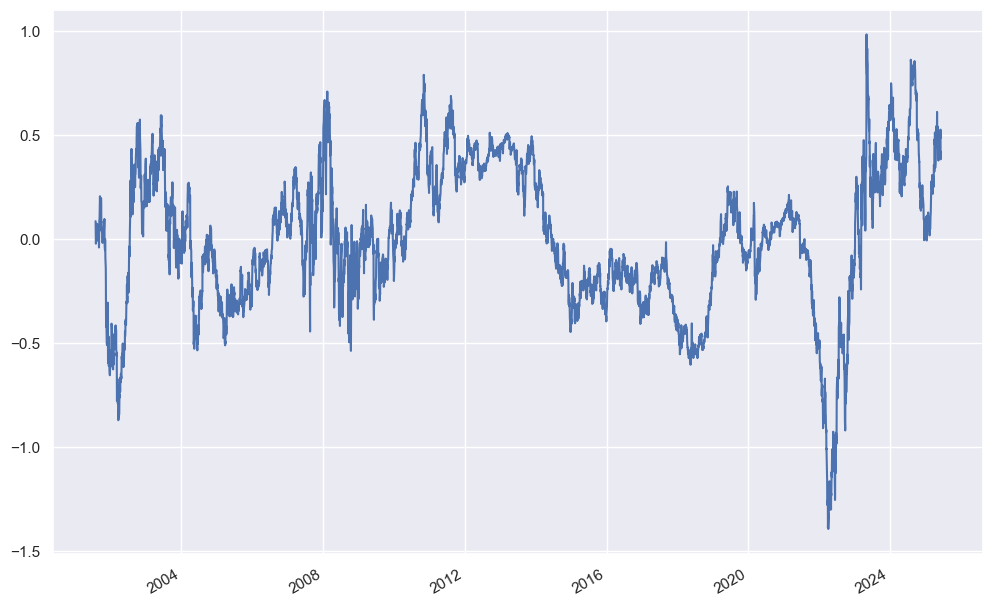

In [23]:
principal_components['PC_3'].plot(figsize =(12,8))

Here We can see the curvature of the yield Curve oscillates around 0